<a href="https://colab.research.google.com/github/romavallejo/TC3009C.600_AIClass/blob/main/P1_M1_%20PythonLib_Statistics/ContaminanteAire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Extracción

In [3]:
import pandas as pd

path_2026 = 'contaminantes_2026.csv'
path_2025 = 'contaminantes_2025.csv'
path_2024 = 'contaminantes_2024.csv'

#extracción de csv raw a df
# Trying with semicolon delimiter due to ParserError: Expected 1 fields in line 10, saw 5
raw_df_26 = pd.read_csv(path_2026, skiprows=9)
raw_df_25 = pd.read_csv(path_2025, skiprows=9)
raw_df_24 = pd.read_csv(path_2024, skiprows=9)

In [4]:
print(raw_df_26.columns)
print(raw_df_25.columns)
print(raw_df_24.columns)

Index(['date', 'id_station', 'id_parameter', 'valor', 'unit'], dtype='object')
Index(['date', 'id_station', 'id_parameter', 'valor', 'unit'], dtype='object')
Index(['date', 'id_station', 'id_parameter', 'value', 'unit'], dtype='object')


In [5]:
raw_df_24.rename(columns={'value': 'valor'}, inplace=True)

unified_raw_df = pd.concat([raw_df_26, raw_df_25, raw_df_24], ignore_index=True)
unified_raw_df.head()

,date,id_station,id_parameter,valor,unit
0,2026-01-01 00:00:00,ACO,CO,NaN,NaN
1,2026-01-01 00:00:00,ACO,NO,NaN,NaN
2,2026-01-01 00:00:00,ACO,NO2,NaN,NaN
3,2026-01-01 00:00:00,ACO,NOX,NaN,NaN
4,2026-01-01 00:00:00,ACO,O3,NaN,NaN


In [6]:
print(f"date de inicio: {unified_raw_df['date'].min()}")
print(f"date de fin: {unified_raw_df['date'].max()}")

date de inicio: 2024-01-01 01:00:00
date de fin: 2026-02-28 23:00:00


## Transformación

In [7]:
#revisar si hay valores nulos
unified_raw_df.isnull().sum()

,0
date,0
id_station,0
id_parameter,0
valor,2357916
unit,352512


In [8]:

unified_raw_df['valor'] = pd.to_numeric(unified_raw_df['valor'].fillna(0), errors='coerce')

unified_raw_df['unit'] = unified_raw_df['unit'].fillna('N/A')

unified_raw_df.isnull().sum()

,0
date,0
id_station,0
id_parameter,0
valor,0
unit,0


In [9]:
#date a datetime
print(unified_raw_df.info())
unified_raw_df['date'] = pd.to_datetime(unified_raw_df['date'], format='mixed')
print(unified_raw_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5394153 entries, 0 to 5394152
Data columns (total 5 columns):
 #   Column        Dtype  
---  ------        -----  
 0   date          object 
 1   id_station    object 
 2   id_parameter  object 
 3   valor         float64
 4   unit          object 
dtypes: float64(1), object(4)
memory usage: 205.8+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5394153 entries, 0 to 5394152
Data columns (total 5 columns):
 #   Column        Dtype         
---  ------        -----         
 0   date          datetime64[ns]
 1   id_station    object        
 2   id_parameter  object        
 3   valor         float64       
 4   unit          object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 205.8+ MB
None


In [13]:
df = unified_raw_df.copy()
df.head()

,date,id_station,id_parameter,valor,unit,year
0,2026-01-01,ACO,CO,0.0,N/A,2026
1,2026-01-01,ACO,NO,0.0,N/A,2026
2,2026-01-01,ACO,NO2,0.0,N/A,2026
3,2026-01-01,ACO,NOX,0.0,N/A,2026
4,2026-01-01,ACO,O3,0.0,N/A,2026


## Medidas de Tendencia Centroal: Media, Mediana Moda

In [14]:
media = df['valor'].mean()
mediana = df['valor'].median()
moda = df['valor'].mode()[0]

print(f"Media: {media}")
print(f"Mediana: {mediana}")
print(f"Moda: {moda}")

# Desglosado por contaminante
tendencia_central = df.groupby('id_parameter')['valor'].agg(['mean', 'median', lambda x: x.mode()[0]])
tendencia_central.columns = ['media', 'mediana', 'moda']
tendencia_central

Media: 11.559507105193354
Mediana: 0.49
Moda: 0.0


,media,mediana,moda
id_parameter,,,
CO,0.336965,0.23,0.0
NO,7.106184,0.00,0.0
NO2,14.046115,11.00,0.0
NOX,19.853442,9.00,0.0
O3,23.286214,13.00,0.0
PM10,20.104949,0.00,0.0
PM2.5,9.022368,0.00,0.0
PMCO,6.098473,0.00,0.0
SO2,1.916438,1.00,0.0


## Calcular medidas de dispersión: varianza, desviación estandar

In [15]:
varianza = df['valor'].var()
desviacion_std = df['valor'].std()

print(f"Varianza: {varianza}")
print(f"Desviación estándar: {desviacion_std}")

# desglosado por contaminante
dispersion = df.groupby('id_parameter')['valor'].agg(['var', 'std'])
dispersion.columns = ['varianza', 'desviacion_std']
dispersion

Varianza: 483.91131668347106
Desviación estándar: 21.997984377744046


,varianza,desviacion_std
id_parameter,,
CO,0.173943,0.417065
NO,444.351543,21.079648
NO2,241.110890,15.527746
NOX,1027.535238,32.055191
O3,781.366884,27.952941
PM10,811.253391,28.482510
PM2.5,177.197964,13.311573
PMCO,141.407649,11.891495
SO2,23.811935,4.879747


## Graficas de distribución

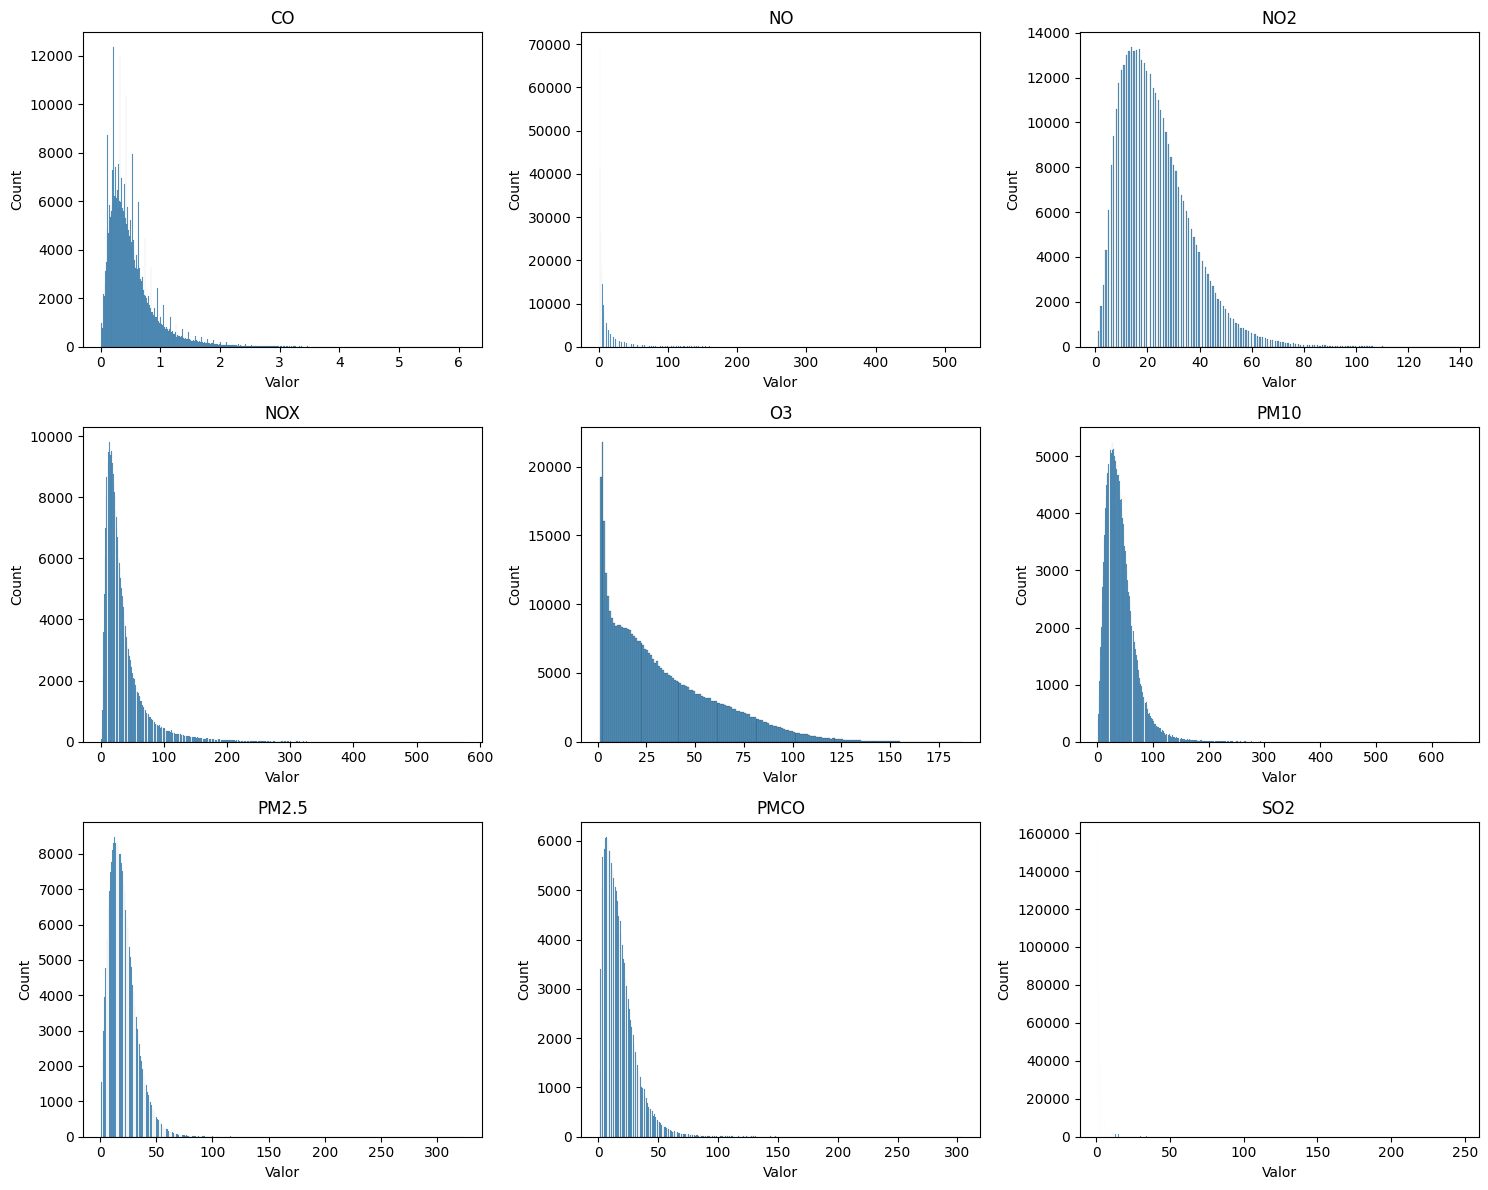

In [18]:
# %% [code]
import matplotlib.pyplot as plt
import seaborn as sns
import math

df_nonzero = df[df['valor'] > 0]

parametros = sorted(df_nonzero['id_parameter'].unique())
n = len(parametros)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = axes.flatten()

for ax, param in zip(axes, parametros):
    sns.histplot(df_nonzero[df_nonzero['id_parameter'] == param]['valor'], ax=ax)
    ax.set_title(param)
    ax.set_xlabel('Valor')

for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()